## Question 1

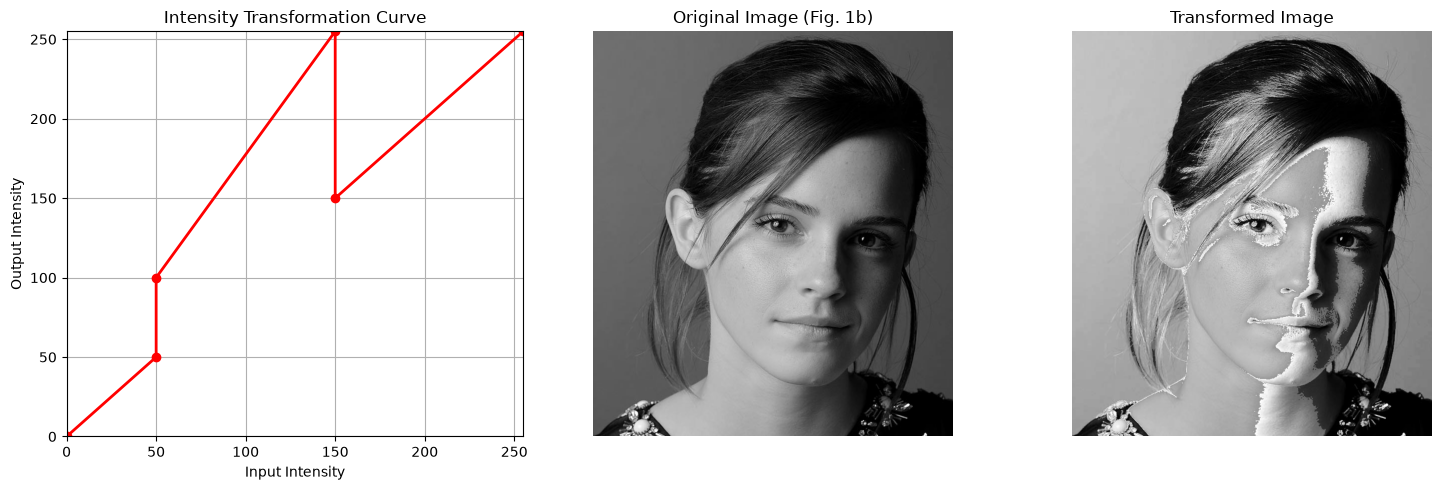

In [114]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    xp = breakpoints[:, 0]
    fp = breakpoints[:, 1]
    transformed_im = np.interp(im, xp, fp).astype(np.uint8)
    return transformed_im

im = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)

breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50, 100],
    [150, 255],
    [150, 150],
    [255, 255]
])

transformed_im = intensity_transform(im, breakpoints)

fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'r-o', linewidth=2, markersize=6)
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image (Fig. 1b)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
plt.title('Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

### After Experimenting with different break points

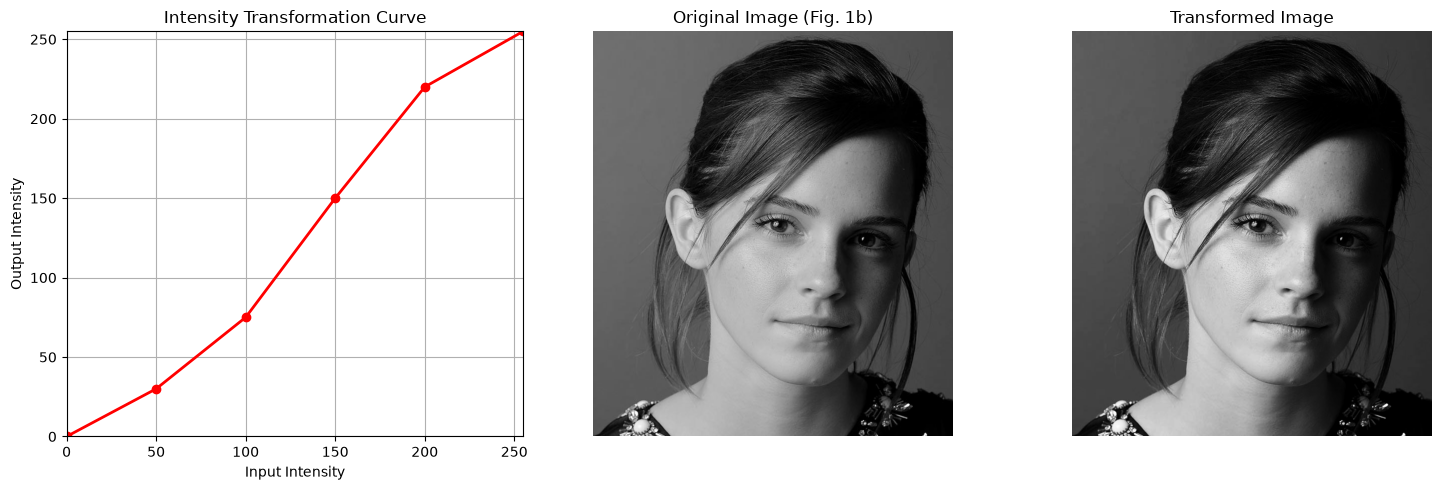

In [115]:
breakpoints = np.array([
    [0, 0],
    [50, 30],
    [100, 75],
    [150, 150],
    [200, 220],
    [255, 255]
])

transformed_im = intensity_transform(im, breakpoints)

fig = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(breakpoints[:, 0], breakpoints[:, 1], 'r-o', linewidth=2, markersize=6)
plt.title('Intensity Transformation Curve')
plt.xlabel('Input Intensity')
plt.ylabel('Output Intensity')
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.grid(True)

plt.subplot(1, 3, 2)
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.title('Original Image (Fig. 1b)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(transformed_im, cmap='gray', vmin=0, vmax=255)
plt.title('Transformed Image')
plt.axis('off')

plt.tight_layout()
plt.show()


## Question 2

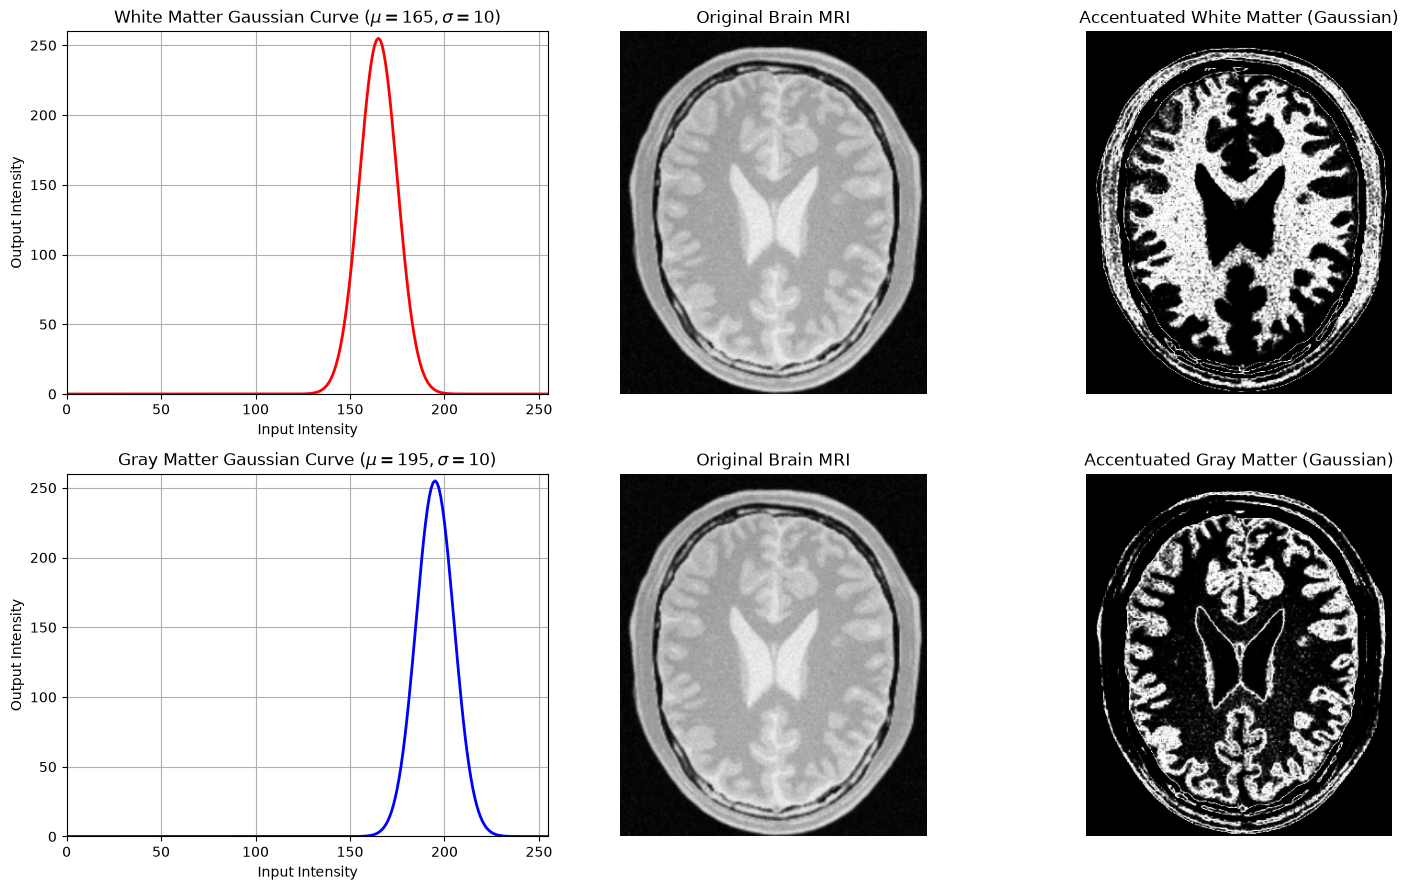

In [116]:
def gaussian_intensity_transform(im, mu, sigma):
    x = im.astype(np.float32)
    transformed = 255.0 * np.exp(-((x - mu)**2) / (2.0 * (sigma**2)))
    return np.clip(transformed, 0, 255).astype(np.uint8)

brain_im = cv.imread('images/fig2.png', cv.IMREAD_GRAYSCALE)

mu_wm, sigma_wm = 165.0, 10.0
wm_gaussian = gaussian_intensity_transform(brain_im, mu_wm, sigma_wm)

mu_gm, sigma_gm = 195.0, 10.0
gm_gaussian = gaussian_intensity_transform(brain_im, mu_gm, sigma_gm)

x_vals = np.arange(0, 256)
curve_wm = 255.0 * np.exp(-((x_vals - mu_wm)**2) / (2.0 * (sigma_wm**2)))
curve_gm = 255.0 * np.exp(-((x_vals - mu_gm)**2) / (2.0 * (sigma_gm**2)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

axes[0, 0].plot(x_vals, curve_wm, 'r-', linewidth=2)
axes[0, 0].set_title(rf'White Matter Gaussian Curve ($\mu={int(mu_wm)}, \sigma={int(sigma_wm)}$)')
axes[0, 0].set_xlabel('Input Intensity'); axes[0, 0].set_ylabel('Output Intensity')
axes[0, 0].set_xlim([0, 255]); axes[0, 0].set_ylim([0, 260])
axes[0, 0].grid(True)

axes[0, 1].imshow(brain_im, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Original Brain MRI')
axes[0, 1].axis('off')

axes[0, 2].imshow(wm_gaussian, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title('Accentuated White Matter (Gaussian)')
axes[0, 2].axis('off')

axes[1, 0].plot(x_vals, curve_gm, 'b-', linewidth=2)
axes[1, 0].set_title(rf'Gray Matter Gaussian Curve ($\mu={int(mu_gm)}, \sigma={int(sigma_gm)}$)')
axes[1, 0].set_xlabel('Input Intensity'); axes[1, 0].set_ylabel('Output Intensity')
axes[1, 0].set_xlim([0, 255]); axes[1, 0].set_ylim([0, 260])
axes[1, 0].grid(True)

axes[1, 1].imshow(brain_im, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Original Brain MRI')
axes[1, 1].axis('off')

axes[1, 2].imshow(gm_gaussian, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title('Accentuated Gray Matter (Gaussian)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()